In [6]:
import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "/content/Metro_Interstate_Traffic_Volume.csv"
df1 = pd.read_csv(file_path)
df= df1.copy()
df['date_time']= pd.to_datetime(df['date_time'])
df['holiday'] = df['holiday'].fillna('normal_day')
df['Ctemp']=df['temp']-273.15
df.info()
df.head()
df.describe()
df.loc[df['temp'] == 0, 'temp'] = 297
df['Ctemp'] = df['temp'] - 273.15
df2 = df.groupby('weather_main')['traffic_volume'].sum().sort_values(ascending=False).reset_index()
print(df2)
df.drop_duplicates().shape

"""

Converted date_time to datetime64 dtype
Converted Kelvin to Celsius
There were 17 duplicate values
Grouped weather data by traffic volume and found out traffic volume is highest
during cloudy or clear weather by a significant amount.

"""


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              48204 non-null  object        
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  object        
 6   weather_description  48204 non-null  object        
 7   date_time            48204 non-null  datetime64[ns]
 8   traffic_volume       48204 non-null  int64         
 9   Ctemp                48204 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 3.7+ MB
    weather_main  traffic_volume
0         Clouds        54870172
1          Clear        40921675
2           Rain        188

'\n\nConverted date_time to datetime64 dtype\nConverted Kelvin to Celsius\nThere were 17 duplicate values\nGrouped weather data by traffic volume and found out traffic volume is highest\nduring cloudy or clear weather by a significant amount.\n\n'

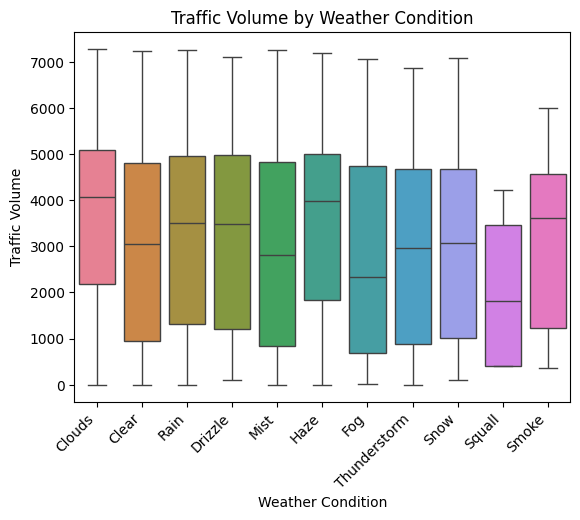

'\n\nThe median for Cloudy, Haze and Smoke are higher than the rest\nsignifying high density of traffic under those specific conditions.\nThe median for Fog and Squall is lower than the rest meaning traffic density\nis lower for those specific conditions.\n\n'

In [7]:
sns.boxplot(x='weather_main', y='traffic_volume', data=df, hue='weather_main')
plt.title('Traffic Volume by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Traffic Volume')
plt.xticks(rotation=45, ha='right')
plt.show()

"""

The median for Cloudy, Haze and Smoke are higher than the rest
signifying high density of traffic under those specific conditions.
The median for Fog and Squall is lower than the rest meaning traffic density
is lower for those specific conditions.

"""

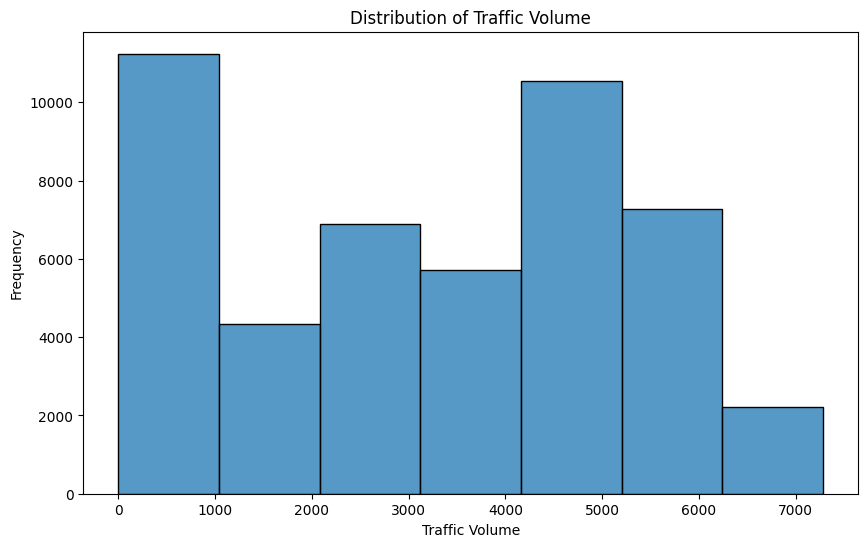

'\n\nAfter observing the distribution of traffic volume, We can confirm that the most\nfrequent traffic density is between 0-1000 and 4000-5000 vehicles approximately.\nThere is an average of 3280 vehicles as the traffic volume with the maximum vehicles\nbeing 7280 vehicles in a single hour.\n'

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['traffic_volume'], bins=7)
plt.title('Distribution of Traffic Volume')
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')
plt.show()
df['traffic_volume'].describe()

"""

After observing the distribution of traffic volume, We can confirm that the most
frequent traffic density is between 0-1000 and 4000-5000 vehicles approximately.
There is an average of 3280 vehicles as the traffic volume with the maximum vehicles
being 7280 vehicles in a single hour.
"""

In [63]:
df['year']= df['date_time'].dt.strftime('%Y')
df['month']= df['date_time'].dt.strftime('%m')
df['day']= df['date_time'].dt.strftime('%d')
df['hour']= df['date_time'].dt.strftime('%H')
df['weekday']=df['date_time'].dt.strftime('%A')
df.head()

"""

Converterd the date_time column to add year, month, day, hour and day of the week.

"""

'\n\nConverterd the date_time column to add year, month, day, hour and day of the week.\n\n'

In [64]:
df['year'] = df['year'].astype('int64')
df['month'] = df['month'].astype('int64')
df['day'] = df['day'].astype('int64')
df['hour'] = df['hour'].astype('int64')
df.dtypes
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,Ctemp,year,month,day,hour,weekday
0,normal_day,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,15.13,2012,10,2,9,Tuesday
1,normal_day,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,16.21,2012,10,2,10,Tuesday
2,normal_day,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,16.43,2012,10,2,11,Tuesday
3,normal_day,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,16.98,2012,10,2,12,Tuesday
4,normal_day,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,17.99,2012,10,2,13,Tuesday


/tmp/ipykernel_2478/4255616067.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df, x=df['weekday'], y=df['traffic_volume'], hue=df['weekday'], ci=False)


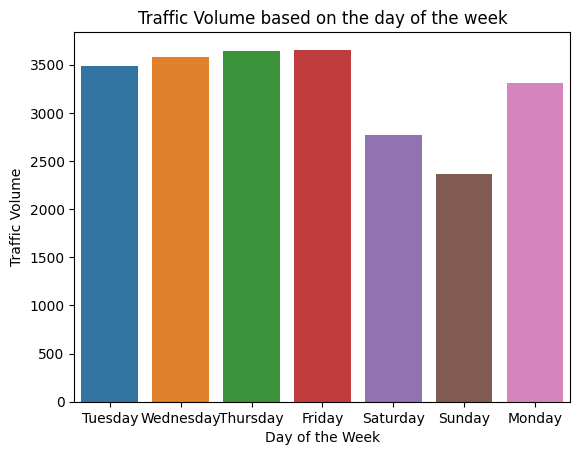

'\n\nAs expected from the barplot for the traffic volume for each day of the week, Saturday\nand Sunday are the days with the lowest traffic volume.\n\n'

In [66]:
sns.barplot(data=df, x=df['weekday'], y=df['traffic_volume'], hue=df['weekday'], ci=False)
plt.title('Traffic Volume based on the day of the week')
plt.xlabel('Day of the Week')
plt.ylabel('Traffic Volume')
plt.show()

"""

As expected from the barplot for the traffic volume for each day of the week, Saturday
and Sunday are the days with the lowest traffic volume.

"""

/tmp/ipykernel_2478/23156178.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df, x=df['month'], y=df['traffic_volume'], palette='Set3', ci=False)
/tmp/ipykernel_2478/23156178.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=df['month'], y=df['traffic_volume'], palette='Set3', ci=False)


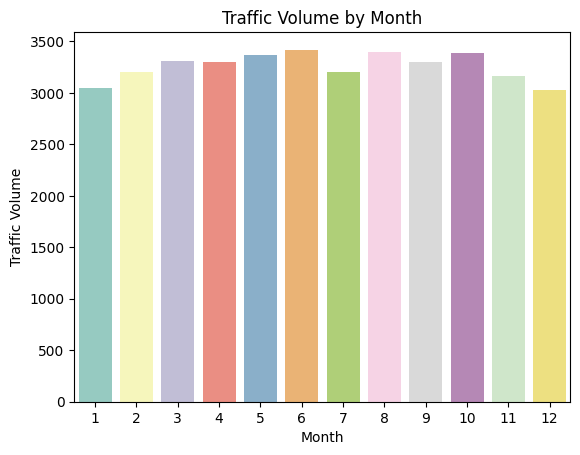

'\n\nFrom the bar graph for traffic volume versus each month, Winter months from November\nto February have the lowest traffic volume. Summer months from June to August have\nthe highest traffic volume except for July which seems unusual.\n\n'

In [67]:
sns.barplot(data=df, x=df['month'], y=df['traffic_volume'], palette='Set3', ci=False)
plt.title('Traffic Volume by Month')
plt.xlabel('Month')
plt.ylabel('Traffic Volume')
plt.show()

"""

From the bar graph for traffic volume versus each month, Winter months from November
to February have the lowest traffic volume. Summer months from June to August have
the highest traffic volume except for July which seems unusual.

"""

/tmp/ipykernel_2478/1527768245.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data= july_years, x=july_years['year'], y=july_years['traffic_volume'], palette='Spectral',ci=False)
/tmp/ipykernel_2478/1527768245.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= july_years, x=july_years['year'], y=july_years['traffic_volume'], palette='Spectral',ci=False)


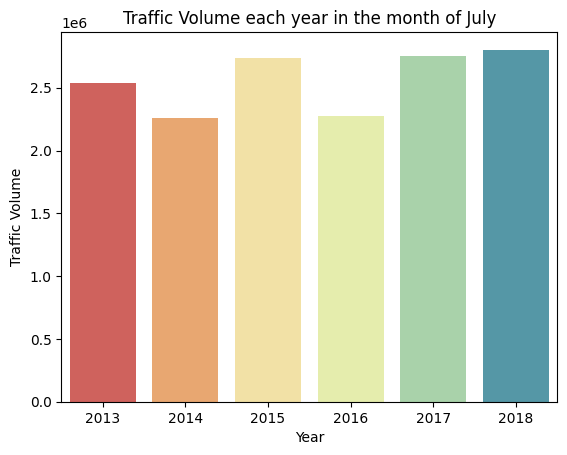

'\n\nJudging from the bar graph below for the traffic density for each year in the month of\nJuly, we can observe that 2016 and 2014 have significantly lower traffic density which\nis the reason behind July having lower traffic volume in the Summer months. This could\nbe because of road construction work or the road being closed down for other reasons.\n\n'

In [77]:
july_years = df[df['month'] == 7].groupby('year')['traffic_volume'].sum().sort_values(ascending=False).reset_index()
july_years.head(10)
sns.barplot(data= july_years, x=july_years['year'], y=july_years['traffic_volume'], palette='Spectral',ci=False)
plt.title('Traffic Volume each year in the month of July')
plt.xlabel('Year')
plt.ylabel('Traffic Volume')
plt.show()


"""

Judging from the bar graph below for the traffic density for each year in the month of
July, we can observe that 2016 and 2014 have significantly lower traffic density which
is the reason behind July having lower traffic volume in the Summer months. This could
be because of road construction work or the road being closed down for other reasons.

"""

/tmp/ipykernel_2478/467247373.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df, x=df['year'], y=df['traffic_volume'], palette='Set2', ci=False)
/tmp/ipykernel_2478/467247373.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=df['year'], y=df['traffic_volume'], palette='Set2', ci=False)


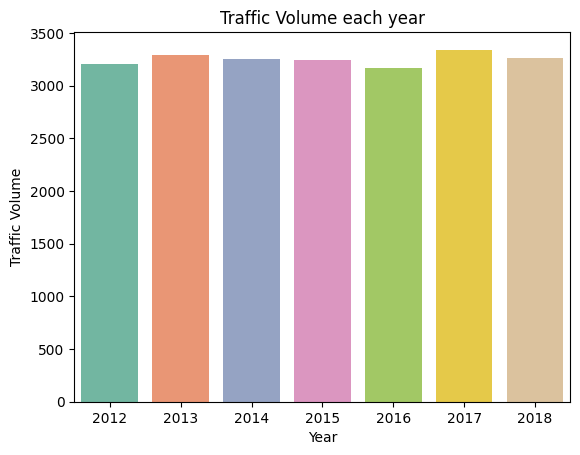

'\n\nTraffic volume was observed to be highest in 2017 and lowest in 2016. This also shows us that the road construction did NOT reduce the overall\ntraffic volume in the years 2014 and 2016 (but only for the month of July).\n\n'

In [69]:
sns.barplot(data=df, x=df['year'], y=df['traffic_volume'], palette='Set2', ci=False)
plt.title('Traffic Volume each year')
plt.xlabel('Year')
plt.ylabel('Traffic Volume')
plt.show()

"""

Traffic volume was observed to be highest in 2017 and lowest in 2016. This also shows us that the road construction did NOT reduce the overall
traffic volume in the years 2014 and 2016 (but only for the month of July).

"""

/tmp/ipykernel_2478/3425979559.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df, y=df['weather_description'], x=df['traffic_volume'], hue=df['weather_description'], ci=False)


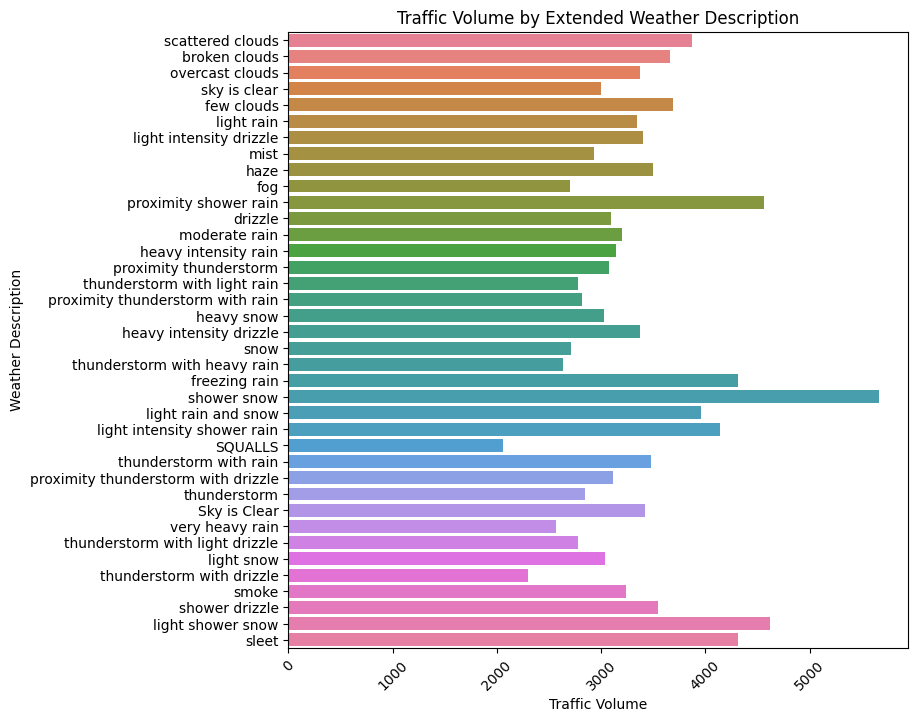

'\n\nFrom the graph with the detailed weather description below we can infer that any form of rain or snow causes a decent spike in\ntraffic volume. Shower snow and proximity shower rain in particular have the highest observed traffic density.\nThis could be due to slower driving speeds causing more congestions and more people preferring to go by car to avoid walking or biking/cycling.\n\n'

In [28]:
df3= df.groupby('weather_description')['traffic_volume'].sum().sort_values(ascending=False).reset_index()
df3.head(10)
plt.figure(figsize = (8, 8))
sns.barplot(data=df, y=df['weather_description'], x=df['traffic_volume'], hue=df['weather_description'], ci=False)
plt.title('Traffic Volume by Extended Weather Description')
plt.ylabel('Weather Description')
plt.xlabel('Traffic Volume')
plt.xticks(rotation=45)
plt.show()

"""

From the graph with the detailed weather description below we can infer that any form of rain or snow causes a decent spike in
traffic volume. Shower snow and proximity shower rain in particular have the highest observed traffic density.
This could be due to slower driving speeds causing more congestions and more people preferring to go by car to avoid walking or biking/cycling.

"""

(23877, 15)
(24327, 15)


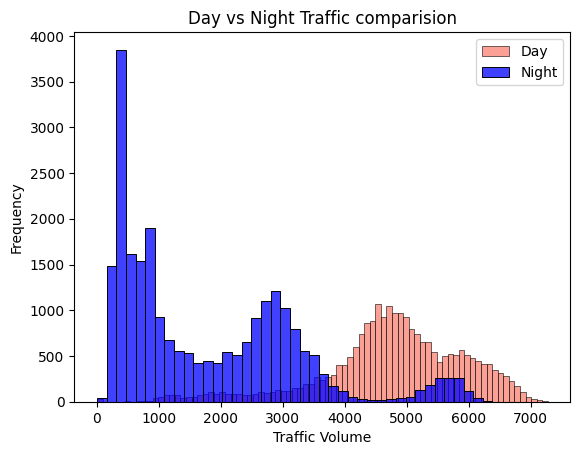

'\n\nComparing the day vs night traffic densities we can observe that night traffic is\nsignificantly lower than day traffic which is to be expected as most individuals are\nback home from work or asleep. There are some exceptions for traffic density during\nnighttime which needs to be investigated.\n\n'

In [30]:
day = df.copy()[(df['date_time'].dt.hour >= 7) & (df['date_time'].dt.hour < 19)]
print(day.shape)

night = df.copy()[(df['date_time'].dt.hour >= 19) | (df['date_time'].dt.hour < 7)]
print(night.shape)

sns.histplot(data=day['traffic_volume'], color='salmon', label='Day')
sns.histplot(data=night['traffic_volume'], color='blue', label='Night')
plt.title('Day vs Night Traffic comparision')
plt.ylabel('Frequency')
plt.xlabel('Traffic Volume')
plt.legend()
plt.show()

"""

Comparing the day vs night traffic densities we can observe that night traffic is
significantly lower than day traffic which is to be expected as most individuals are
back home from work or asleep. There are some exceptions for traffic density during
nighttime which needs to be investigated.

"""

/tmp/ipykernel_2478/3013477059.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=night, x=night['holiday'], y=night['traffic_volume'], palette='Set2', ci=False)
/tmp/ipykernel_2478/3013477059.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=night, x=night['holiday'], y=night['traffic_volume'], palette='Set2', ci=False)


'\n\nFrom this graph, We can conclude that holidays are NOT the main cause of traffic during the night.\n\n'

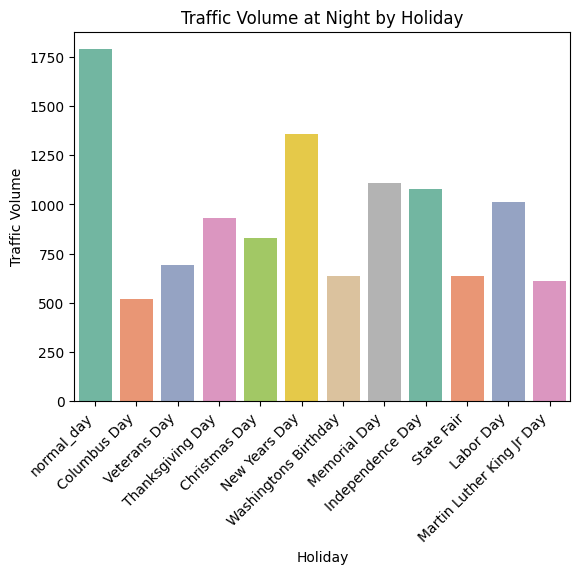

In [32]:
night_fest= night[night['holiday']!='normal_day']
night_fest.shape
sns.barplot(data=night, x=night['holiday'], y=night['traffic_volume'], palette='Set2', ci=False)
plt.title('Traffic Volume at Night by Holiday')
plt.xlabel('Holiday')
plt.ylabel('Traffic Volume')
plt.xticks(rotation=45, ha='right')

"""

From this graph, We can conclude that holidays are NOT the main cause of traffic during the night.

"""

In [19]:
dense_night= night[night['traffic_volume']>=5000]
dense_night.shape

"""
There are 1289 outliers with traffic higher than 5000 vehicles during the night.

"""

(1289, 15)

/tmp/ipykernel_2478/3707406176.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=night, x='weather_main', y='traffic_volume', palette='viridis')


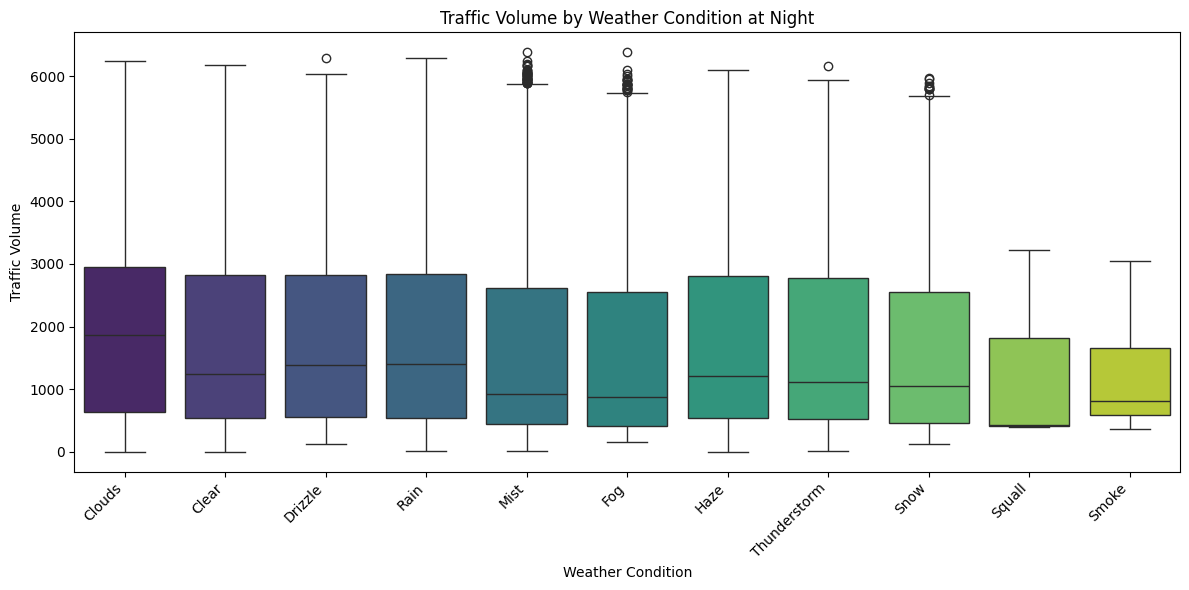

'\n\nFrom the boxplot below we can see that most of the outliers with high traffic density\nduring the night are appearing during fog,mist and snow. This hypothesis is further\nconfirmed when we check by month to see the outliers appearing during the winter months.\n\n'

In [33]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=night, x='weather_main', y='traffic_volume', palette='viridis')
plt.title('Traffic Volume by Weather Condition at Night')
plt.xlabel('Weather Condition')
plt.ylabel('Traffic Volume')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

"""

From the boxplot below we can see that most of the outliers with high traffic density
during the night are appearing during fog,mist and snow. This hypothesis is further
confirmed when we check by month to see the outliers appearing during the winter months.

"""

/tmp/ipykernel_2478/1163794679.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=night, x='month', y='traffic_volume', palette='viridis')


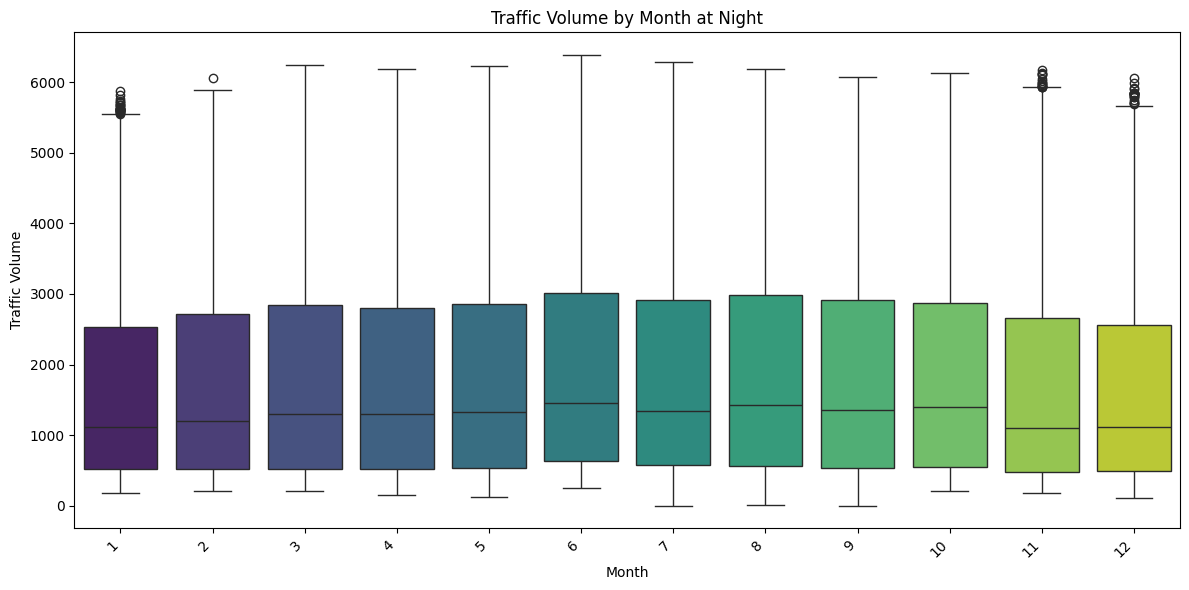

In [34]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=night, x='month', y='traffic_volume', palette='viridis')
plt.title('Traffic Volume by Month at Night')
plt.xlabel('Month')
plt.ylabel('Traffic Volume')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()